✅ YOLO ONNX caricato
✅ Foundry GPT-4o configurato
🚀 Avvio analisi su 123.jpg...

SAFETY ANALYSIS REPORT
[YOLO11-ONNX] 4 detections (Person(0.81), Glove(0.69), Helmet(0.43), Person(0.43)) in 334.1ms
[Foundry-GPT4o] 11 detections (person(0.99), no_helmet(0.95), no_vest(0.95), glove(0.98), boot(0.90), person(0.99), no_helmet(0.95), no_vest(0.95), glove(0.98), boot(0.90), unsafe_behavior(0.85)) in 27178.9ms | 5 VIOLATION(S) FOUND: ['no_helmet', 'no_vest', 'no_helmet', 'no_vest', 'unsafe_behavior']
  ⚠️  no_helmet (conf=0.95)
  ⚠️  no_vest (conf=0.95)
  ⚠️  no_helmet (conf=0.95)
  ⚠️  no_vest (conf=0.95)
  ⚠️  unsafe_behavior (conf=0.85)



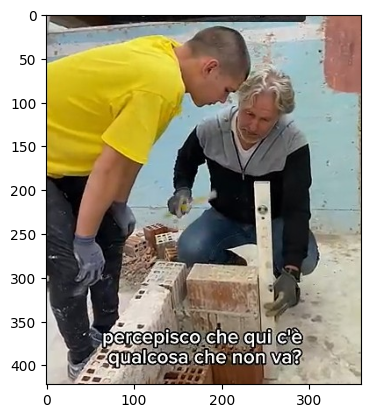

In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv
from src.visual_security.analyzer import YOLOAnalyzer, FoundryGPT4oAnalyzer, SafetyAnalyzerPipeline
from matplotlib import pyplot as plt

load_dotenv()

YOLO_WEIGHTS = "weights/dataset_1/yolo_nano_640/best.onnx"

analyzers = []

# YOLO
if Path(YOLO_WEIGHTS).exists():
    analyzers.append(YOLOAnalyzer(model_path=YOLO_WEIGHTS))
    print("✅ YOLO ONNX caricato")
else:
    print(f"⚠️  YOLO ONNX non trovato in {YOLO_WEIGHTS}, skip.")

# Foundry GPT-4o
if os.getenv("AZURE_OPENAI_KEY"):
    analyzers.append(FoundryGPT4oAnalyzer(api_key=os.getenv("AZURE_OPENAI_KEY"), endpoint=os.getenv("AZURE_OPENAI_URL")))
    print("✅ Foundry GPT-4o configurato")
else:
    print("⚠️  AZURE_OPENAI_KEY non impostato, skip.")

# Esegui l'analisi
# TEST_IMAGE = "data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg"
TEST_IMAGE = "123.jpg"
pipeline = SafetyAnalyzerPipeline(analyzers)

if Path(TEST_IMAGE).exists():
    print(f"🚀 Avvio analisi su {TEST_IMAGE}...")
    plt.imshow(plt.imread(TEST_IMAGE))
    results = pipeline.run(TEST_IMAGE)
    pipeline.print_report(results)
else:
    print(f"⚠️  Immagine non trovata: {TEST_IMAGE}")
    print("   Modifica TEST_IMAGE con il path corretto.")

In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
from src.visual_security.analyzer import YOLOAnalyzer, Florence2Analyzer, MoondreamAnalyzer, SafetyHybridPipeline

load_dotenv()

YOLO_WEIGHTS = "weights/dataset_1/yolo_nano_640/best.onnx"
TEST_IMAGE = "data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg"

yolo = YOLOAnalyzer(model_path=YOLO_WEIGHTS)
florence = Florence2Analyzer(model_id="microsoft/Florence-2-base", device="cpu")
moondream = MoondreamAnalyzer(device="cpu")
hybrid_pipeline = SafetyHybridPipeline(primary_yolo=yolo, validator_vlm=moondream)

if Path(TEST_IMAGE).exists():
    print(f"🚀 Avvio Analisi Ibrida su: {TEST_IMAGE}")
    img_original = cv.imread(TEST_IMAGE)
    rows, cols = img_original.shape[:2]

    for i in range(12):
        tx = -(i * 5)
        M = np.float32([[1, 0, tx], [0, 1, 0]])
        img_shifted = cv.warpAffine(img_original, M, (cols, rows))

        TEMP_SHIFTED_PATH = "temp_shifted.jpg"
        cv.imwrite(TEMP_SHIFTED_PATH, img_shifted)

        result = hybrid_pipeline.analyze_frame(TEMP_SHIFTED_PATH)

        if result["status"] == "ALERT":
            print(f"⚠️  ALLERTA CONFERMATA al frame {i} (Shift: {tx}px): {result['validated_violations']}")
            plt.imshow(cv.cvtColor(img_shifted, cv.COLOR_BGR2RGB))
            plt.title(f"Alert at frame {i}")
            plt.show()
            break
        else:
            print(f"[{i}] Analisi... Shift: {tx}px | Status: {result['status']}")

# Pulizia
# if os.path.exists(TEMP_SHIFTED_PATH):
#     os.remove(TEMP_SHIFTED_PATH)

🚀 Avvio Analisi Ibrida su: data/test/images/105_JPG_jpg.rf.5708a5ef86ade6c986f877fabdb267bd.jpg
[0] Analisi... Shift: 0px | Status: SAFE
[1] Analisi... Shift: -5px | Status: SAFE
[2] Analisi... Shift: -10px | Status: SAFE
[3] Analisi... Shift: -15px | Status: SAFE
[4] Analisi... Shift: -20px | Status: SAFE
[5] Analisi... Shift: -25px | Status: SAFE
[6] Analisi... Shift: -30px | Status: SAFE
[7] Analisi... Shift: -35px | Status: SAFE
[8] Analisi... Shift: -40px | Status: SAFE
[9] Analisi... Shift: -45px | Status: SAFE
[10] Analisi... Shift: -50px | Status: SAFE
[11] Analisi... Shift: -55px | Status: SAFE


In [2]:
from src.visual_security.analyzer import YOLOAnalyzer, Florence2Analyzer, MoondreamAnalyzer, SafetyHybridPipeline
from src.visual_security.video_tracker import build_hybrid_tracker

tracker = build_hybrid_tracker(
    yolo_model_path="weights/dataset_1/yolo_nano_640/best.onnx",
    vlm_backend="moondream",
    vlm_device="cpu",
    persistence_frames=4,
    window_frames=8,
    skip_frames=2,
    display=True,
    save_output="output/annotated.mp4",
    alert_log="output/alerts.json",
    yolo_conf=0.30,
    verbose=True,
)
tracker.run("test.mp4")


[frame 1] 6 det → 2 persone
  Persona#1(conf=0.61) trovati={'Helmet': 1, 'Vest': 1, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Glove', 'Shoe'] [VLM→]
  Persona#3(conf=0.59) trovati={'Helmet': 0, 'Vest': 0, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Helmet', 'Vest', 'Glove', 'Shoe'] [VLM→]

[frame 3] 4 det → 2 persone
  Persona#2(conf=0.62) trovati={'Helmet': 0, 'Vest': 0, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Helmet', 'Vest', 'Glove', 'Shoe'] [VLM→]
  Persona#3(conf=0.57) trovati={'Helmet': 0, 'Vest': 1, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Helmet', 'Glove', 'Shoe'] [VLM→]
[t=0.1s frame=4] 2 violazione/i [Moondream✓]: Persona#2(conf=0.62) trovati={'Helmet': 0, 'Vest': 0, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Helmet', 'Vest', 'Glove', 'Shoe'] [VLM→] | Persona#3(conf=0.57) trovati={'Helmet': 0, 'Vest': 1, 'Glove': 0, 'Shoe': 0} | ⚠️  MANCANTI: ['Helmet', 'Glove', 'Shoe'] [VLM→]

[frame 5] 5 det → 2 persone
  Persona#1(conf=0.65) trovati={'Helmet': 0, 'Vest': 1, 'Glove': 0, 'Shoe':

[FrameAlert(frame_idx=4, timestamp_s=0.10075228371843095, person_results=[PersonPPEResult(person_idx=2, person_bbox=(76.60391235351562, 130.58984375, 305.72607421875, 640.0), person_conf=0.6171940565109253, frame_size=(360, 640), found_ppe={'Helmet': 0, 'Vest': 0, 'Glove': 0, 'Shoe': 0}, missing_ppe=['Helmet', 'Vest', 'Glove', 'Shoe'], associated_ppe=[], needs_vlm_validation=True), PersonPPEResult(person_idx=3, person_bbox=(0.0, 136.8272705078125, 179.119873046875, 536.0460205078125), person_conf=0.5732309818267822, frame_size=(360, 640), found_ppe={'Helmet': 0, 'Vest': 1, 'Glove': 0, 'Shoe': 0}, missing_ppe=['Helmet', 'Glove', 'Shoe'], associated_ppe=[Detection(label='Vest', confidence=0.6248478889465332, bbox=[[0.0, 299.2679138183594], [0.0, 142.04345703125], [177.75897216796875, 142.04345703125], [177.75897216796875, 299.2679138183594]], is_violation=False)], needs_vlm_validation=True)], vlm_confirmed=True, vlm_response="Person#2: [parse error: CloudVL.__init__() got an unexpected k